#Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Read Data dari GitHub

In [ ]:
df = pd.read_excel("https://raw.githubusercontent.com/hastisf/python-data-analyst/master/Final%20Project/Data/Raw/association_rules.xlsx")

# Koneksi Data ke Supabase

In [ ]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

url = URL.create(
    drivername="postgresql",
    username="postgres.ayasnusplkwugywtpqzt",
    password="Hastinafis150226",
    host="aws-1-ap-southeast-1.pooler.supabase.com",
    port=6543,
    database="postgres",
    query={"sslmode": "require"})

engine = create_engine(url)

In [ ]:
df.head(5)

,invoice_code,stock_code,description,quantity,order_date,price,unit,customer_id,country,price_rupiah,...,month,year,revenue,day_of_week,is_weekend,hour_transaction,quantity_category,segment_rfm,basket_size,product_category
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,dollar,17850.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,dollar,17850.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,dollar,17850.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,dollar,17850.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,dollar,17850.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Dataset Asli:
1. invoice_code : 6-digit integral number, code with letter 'c' = cancellation
2. stock_code : 5/6-digit integral number
3. description: product name
4. quantity: the quantities of item per transaction
5. order_date: the day and time of transaction
6. price: product price per unit
7. dollar: USD currency
8. customer_id: 5-digit integral number
9. country: the name of the customer's country


Feature Engineering:
1. price_rupiah: harga dalam rupiah, avg kurs 2010-12 - 2011-12 (Rp 8.790,00)
2. date
3. month
4. year
5. revenue
6. day_of_week: days in a week (1-7). Monday (0) , Sunday(6)
7. is_weekend: Saturday/Sunday
8. hour_transaction
9. quantity_category: category of quantity
10. segment_rfm
11. basket_size: association rules
12. product_category

# Informasi Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   invoice_code       541910 non-null  object        
 1   stock_code         541910 non-null  object        
 2   description        540456 non-null  object        
 3   quantity           541910 non-null  int64         
 4   order_date         541910 non-null  datetime64[ns]
 5   price              541910 non-null  float64       
 6   unit               541910 non-null  object        
 7   customer_id        406830 non-null  float64       
 8   country            541910 non-null  object        
 9   price_rupiah       0 non-null       float64       
 10  date               0 non-null       float64       
 11  month              0 non-null       float64       
 12  year               0 non-null       float64       
 13  revenue            0 non-null       float64 

1. order_date : datetime
2. customer_id : int64

# Describe Dataset

In [ ]:
df.describe()

,quantity,order_date,price,customer_id,price_rupiah,date,month,year,revenue,day_of_week,is_weekend,hour_transaction,quantity_category,segment_rfm,basket_size,product_category
count,541910.000000,541910,541910.000000,406830.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,9.552234,2011-07-04 13:35:22.342307584,4.611138,15287.684160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,218.080957,NaN,96.759765,1713.603074,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Cleaning

## Cek Missing Values

In [ ]:
df.isnull().sum()

,0
invoice_code,0
stock_code,0
description,1454
quantity,0
order_date,0
price,0
unit,0
customer_id,135080
country,0
price_rupiah,541910


1. description : 1454 missing values
2. customer_id : 135080 missing values

## Duplicated Data

In [ ]:
df.duplicated().sum()

np.int64(5268)

data duplicated : 5268

In [ ]:
# Menampilkan duplicated rows, urutkan agar yang duplikat berdekatan
duplicate_rows = df[df.duplicated(keep=False)].sort_values(
    by=['invoice_code', 'stock_code'])

duplicate_rows.head(6)

,invoice_code,stock_code,description,quantity,order_date,price,unit,customer_id,country,price_rupiah,...,month,year,revenue,day_of_week,is_weekend,hour_transaction,quantity_category,segment_rfm,basket_size,product_category
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,dollar,17908.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,dollar,17908.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,dollar,17908.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,dollar,17908.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,dollar,17908.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,dollar,17908.0,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Drop Duplicated Data

In [ ]:
# Menghapus duplikat
df.drop_duplicates(inplace=True)

print(df.duplicated().sum())

0


## Data Type Checking

In [ ]:
# Ubah tipe data menjadi string agar proses pencocokan akurat
df["customer_id"] = df["customer_id"].astype(str)
df["stock_code"] = df["stock_code"].astype(str)
df["invoice_code"] = df["invoice_code"].astype(str)

##Cancelled Orders Checking

In [ ]:
# Pisahkan invoice_code menjadi normal dan cancellation
# order normal: quantity > 0, invoice_code tidak diawali 'C'
df_normal = df[(df["quantity"] > 0) & (
    ~df["invoice_code"].str.startswith("C", na=False))].copy()

# order cancellation: quantity < 0, invoice_code diawali 'C'
df_cancel = df[(df["quantity"] < 0) & (
    df["invoice_code"].str.startswith("C", na=False))].copy()

# Ubah nilai quantity data cancel menjadi positif dan merge
df_cancel["quantity_absolute"] = df_cancel["quantity"].abs()

In [ ]:
# Merge data untuk mencocokkan yang diorder lalu dibatalkan : pasangkan data
# berdasarkan customer_id, stock_code, dan quantity yang sama
matched_cancellations = pd.merge(
    df_normal,
    df_cancel,
    left_on=["customer_id", "stock_code", "quantity"],
    right_on=["customer_id", "stock_code", "quantity_absolute"],
    suffixes=("_order", "_cancel"),)

In [ ]:
total_pasangan = len(matched_cancellations)
print(f"Sebanyak {total_pasangan} baris transaksi yang diorder lalu dibatalkan.\n")

if total_pasangan > 0:
    print("Contoh data yang saling berpasangan (Order vs Cancel):")

    kolom_tampilan = [
        "customer_id",
        "stock_code",
        "description_order",
        "invoice_code_order",
        "quantity_order",
        "invoice_code_cancel",
        "quantity_cancel",
    ]

    print(matched_cancellations[kolom_tampilan])
else:
    print("Tidak ditemukan transaksi dengan pola order-cancel yang sama")

Sebanyak 11967 baris transaksi yang diorder lalu dibatalkan.

Contoh data yang saling berpasangan (Order vs Cancel):
      customer_id stock_code                   description_order  \
0         17850.0      22632           HAND WARMER RED POLKA DOT   
1         17850.0      22632           HAND WARMER RED POLKA DOT   
2         17850.0      21071      VINTAGE BILLBOARD DRINK ME MUG   
3         17850.0      82483  WOOD 2 DRAWER CABINET WHITE FINISH   
4         17850.0      21071      VINTAGE BILLBOARD DRINK ME MUG   
...           ...        ...                                 ...   
11962     15311.0      21313         GLASS HEART T-LIGHT HOLDER    
11963     15311.0      21313         GLASS HEART T-LIGHT HOLDER    
11964     15311.0      21313         GLASS HEART T-LIGHT HOLDER    
11965     17581.0      22083           PAPER CHAIN KIT RETROSPOT   
11966     15804.0      22178     VICTORIAN GLASS HANGING T-LIGHT   

      invoice_code_order  quantity_order invoice_code_cancel  quan

##Handle Cancelled Orders

In [ ]:
# Identifikasi kelompok order dan cancel dengan dataframe sementara
df_normal = df[(df["quantity"] > 0) & (
    ~df["invoice_code"].str.startswith("C", na=False))].copy()

df_cancel = df[(df["quantity"] < 0) & (
    df["invoice_code"].str.startswith("C", na=False))].copy()

df_cancel["quantity_absolute"] = df_cancel["quantity"].abs()

In [ ]:
# Simpan index asli ke kolom sementara
df_normal["original_index"] = df_normal.index
df_cancel["original_index"] = df_cancel.index

In [ ]:
# Gabungkan untuk mencari pasangan yang saling membatalkan
matched = pd.merge(
    df_normal,
    df_cancel,
    left_on=["customer_id", "stock_code", "quantity"],
    right_on=["customer_id", "stock_code", "quantity_absolute"],
    suffixes=("_order", "_cancel")
)

In [ ]:
# Menentukan list index yang harus di drop
# Ambil index dari transaksi NORMAL yang memiliki pasangan cancel (Hapus)
index_order_berpasangan = matched["original_index_order"].tolist()

# Cari transaksi CANCEL yang TIDAK memiliki pasangan order (Hapus)
index_cancel_semua = df_cancel["original_index"].tolist()
index_cancel_berpasangan = matched["original_index_cancel"].tolist()

# Semua index cancel - index cancel yang punya pasangan
index_cancel_tidak_berpasangan = list(set(index_cancel_semua) -
                                      set(index_cancel_berpasangan))

# Gabungkan kedua daftar index yang harus dibuang
index_harus_drop = index_order_berpasangan + index_cancel_tidak_berpasangan

# Hapus langsung dari dataframe utama 'df'
df.drop(index=index_harus_drop, inplace=True)

In [ ]:
print(f"Transaksi Order Normal (yang dicancel) dihapus : {len(index_order_berpasangan)} baris")
print(f"Transaksi Cancel tanpa order dihapus : {len(index_cancel_tidak_berpasangan)} baris")
print(f"Transaksi Cancel yang punya pasangan berhasil di-KEEP: {len(index_cancel_berpasangan)} baris")
print(f"Sisa baris akhir di dataframe 'df': {len(df)}")

Transaksi Order Normal (yang dicancel) dihapus : 11967 baris
Transaksi Cancel tanpa order dihapus : 5661 baris
Transaksi Cancel yang punya pasangan berhasil di-KEEP: 11967 baris
Sisa baris akhir di dataframe 'df': 522673


## Handle Quantity & Price =< 0

In [ ]:
# Isi description kosong berdasarkan stock_code

# Cek data tidak memiliki spasi berlebih
df['stock_code'] = df['stock_code'].astype(str).str.strip()

# Cek description kosong (NaN,'nan','')
is_missing_desc = df['description'].isna() | (
    df['description'].astype(str).str.strip() == '') | (
        df['description'].astype(str).str.lower() == 'nan')

jumlah_kosong_awal = is_missing_desc.sum()
print(f"Terdapat {jumlah_kosong_awal} baris dengan description kosong.")

if jumlah_kosong_awal > 0:
    # Mapping dari data dengan description TIDAK kosong
    # Ambil modus description untuk setiap stock_code
    referensi_produk = df[~is_missing_desc].groupby(
        'stock_code')['description'].agg(
        lambda x: x.mode()[0] if not x.mode().empty else np.nan
    )

Terdapat 1453 baris dengan description kosong.


In [ ]:
# Isi description kosong menggunakan referensi_produk
df.loc[is_missing_desc, 'description'] = df.loc[
    is_missing_desc,'stock_code'].map(referensi_produk)

# Cek apakah stock_code belum pernah ada di dataset
sisa_kosong = df['description'].isna().sum()
print(f"Sisa description kosong: {sisa_kosong}")

# Jika masih ada sisa karena stock_code tidak dikenali sistem
if sisa_kosong > 0:
  df['description'] = df['description'].fillna("UNKNOWN PRODUCT")

print("description yang tidak bereferensi nama menjadi 'UNKNOWN PRODUCT')")



Sisa description kosong: 116
description yang tidak bereferensi nama menjadi 'UNKNOWN PRODUCT')


In [ ]:
# Hapus transaksi normal dengan qty dan price <= 0

# Cek tipe data numerik
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

total_awal = len(df)

# Buat dua kelompok kondisi yang boleh disimpan

# 1: Transaksi Cancel (Invoice diawali 'C') -> simpan
mask_cancel = df['invoice_code'].astype(str).str.startswith("C", na=False)

# 2: Transaksi Normal (Bukan 'C') dengan  Quantity > 0 & Price > 0
mask_normal_valid = (~df['invoice_code'].astype(str).str.startswith(
    "C", na=False)) & (df['quantity'] > 0) & (df['price'] > 0)

# Ambil semua data transaksi cancel atau transaksi normal
df = df[mask_cancel | mask_normal_valid].copy()

total_akhir = len(df)
jumlah_dihapus = total_awal - total_akhir

print(f"{jumlah_dihapus} baris transaksi normal dengan quantity/price <= 0")

2499 baris transaksi normal dengan quantity/price <= 0


## Nilai Unik di Invoice Code

In [ ]:
# Ambil karakter pertama pada invoice_code (string)
df['awalan'] = df['invoice_code'].astype(str).str[0]

# Cek karakter yang ada di awal
print(df['awalan'].value_counts())

awalan
5    516583
C      3590
A         1
Name: count, dtype: int64


In [ ]:
from IPython.display import display

# Filter baris yang invoice_code diawali huruf 'A'
baris_unik = df[df['invoice_code'].astype(str).str.startswith('A')]

display(baris_unik)

,invoice_code,stock_code,description,quantity,order_date,price,unit,customer_id,country,price_rupiah,...,year,revenue,day_of_week,is_weekend,hour_transaction,quantity_category,segment_rfm,basket_size,product_category,awalan
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,dollar,nan,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A


1. invoice_code dengan awalan A = 'Adjust bad dept' dengan customer_id bernilai NaN
2. "Bad Debt" / Piutang Macet terjadi ketika ada pelanggan yang membeli dengan sistem tempo/kredit dan tidak bisa membayar tagihan karena perusahaan bangkrut, kabur, dll
3. "Adjust" / Penyesuaian -> uang  tidak akan pernah kembali sehingga Finance harus melakukan penyesuaian pada sistem untuk menghapus nilai piutang dari pembukuan agar laporan keuangan akhir perusahaan tetap akurat.

### Handle 'Adjust Bad Debt' pada Description

In [ ]:
# Menghapus baris yang memiliki deskripsi 'Adjust bad debt'
df = df[df['description'] != 'Adjust bad debt']

In [ ]:
df.isnull().sum()

,0
invoice_code,0
stock_code,0
description,0
quantity,0
order_date,0
price,0
unit,0
customer_id,0
country,0
price_rupiah,520173


##Nilai Unik pada Stock Code

###Tanpa Angka

In [ ]:
# Cari stock_code berisi huruf, tanpa angka
kode_non_numerik = df[~df['stock_code'].astype(
    str).str.contains(r'\d', na=False)]

print(kode_non_numerik[['stock_code', 'description']].drop_duplicates())

          stock_code                 description
45              POST                     POSTAGE
2239               M                      Manual
4406    BANK CHARGES                Bank Charges
14436              S                     SAMPLES
14514      AMAZONFEE                  AMAZON FEE
40383              m                      Manual
75004            DOT              DOTCOM POSTAGE
84016       DCGSSBOY              BOYS PARTY BAG
84017      DCGSSGIRL             GIRLS PARTY BAG
157195          PADS  PADS TO MATCH ALL CUSHIONS


1. POST & DOT (POSTAGE / DOTCOM POSTAGE): ongkos kirim
2. M & m (Manual): Input manual oleh staf (koreksi harga atau transaksi luar sistem)
3. BANK CHARGES: Biaya administrasi bank
4. AMAZONFEE: Biaya komisi atau pendaftaran ke platform Amazon
5. S (SAMPLES): Sampel gratis yang dikirimkan ke mitra -> bukan transaksi penjualan
6. BOYS dan GIRLS PARTY BAG: tas bingkisan ulang tahun anak-anak (keep)
7. PADS: bantalan/busa untuk sofa atau bantal (keep)

###Kurang dari 5 Karakter

In [ ]:
# Ambil stock_code unik
unik_kode = pd.Series(df['stock_code'].unique().astype(str))

# Cari kode yang kurang dari 5 karakter
kode_pendek = unik_kode[unik_kode.str.len() < 5]

print(df[df['stock_code'].isin(kode_pendek)]
 [['stock_code', 'description']].drop_duplicates())

       stock_code                 description
45           POST                     POSTAGE
2239            M                      Manual
14436           S                     SAMPLES
19975          C2                    CARRIAGE
40383           m                      Manual
75004         DOT              DOTCOM POSTAGE
157195       PADS  PADS TO MATCH ALL CUSHIONS


C2 : CARRIAGE ->  Ongkos Kirim
Jika tetap dibiarkan di dalam dataset, sistem akan membaca seolah-olah C2 adalah sebuah barang yang sering dibeli bersamaan dengan produk lain.

###Hapus Data dengan Stock_Code Operasional

In [ ]:
# Daftar stock_code operasional yang ingin dihapus
kode_dibuang = ['POST', 'DOT', 'M', 'm', 'BANK CHARGES', 'AMAZONFEE', 'S', 'C2']

# Timpa dataframe 'df' lama dengan hasil data bersih
df = df[~df['stock_code'].isin(kode_dibuang)]

# Pastikan kode tersebut sudah dihapus dari 'df'
print(f"Baris kode operasional di df sebanyak: {len(df[df['stock_code'].isin(kode_dibuang)])}")

Baris kode operasional di df sebanyak: 0


## Deskripsi dengan Huruf Kecil

In [ ]:
# Cek deskripsi dengan huruf kecil/bukan nama produk standar dengan pola r'[a-z]'
catatan_manual = df[df['description'].astype(
    str).str.contains(r'[a-z]', na=False)]

print(catatan_manual[['stock_code', 'description']].drop_duplicates().head(10))

     stock_code                         description
482       21705             BAG 500g SWIRLY MARBLES
918      46000M        POLYESTER FILLER PAD 45x45cm
1963      21704             BAG 250g SWIRLY MARBLES
2038     46000R        POLYESTER FILLER PAD 45x30cm
2039     46000S        POLYESTER FILLER PAD 40x40cm
2068      22686      FRENCH BLUE METAL DOOR SIGN No
2567      21594       Dr. Jam's Arouzer Stress Ball
3082      21703             BAG 125g SWIRLY MARBLES
3305      22965  3 TRADITIONAl BISCUIT CUTTERS  SET
6438     84247K      FOLK ART GREETING CARD,pack/12


### Handle Voucher pada Description

In [ ]:
# Daftar nama voucher yang ingin dicari stock_code-nya
daftar_voucher = [
    'Dotcomgiftshop Gift Voucher £40.00',
    'Dotcomgiftshop Gift Voucher £50.00',
    'Dotcomgiftshop Gift Voucher £30.00',
    'Dotcomgiftshop Gift Voucher £20.00',
    'Dotcomgiftshop Gift Voucher £10.00',
    'Dotcomgiftshop Gift Voucher £100.00'
]

# Filter data berdasarkan daftar di atas dan ambil pasangan uniknya
voucher_unik = df[df['description'].isin(daftar_voucher)][['description', 'stock_code','quantity','price']].drop_duplicates()

display(voucher_unik)

,description,stock_code,quantity,price
38248,Dotcomgiftshop Gift Voucher £40.00,gift_0001_40,1,34.04
42057,Dotcomgiftshop Gift Voucher £50.00,gift_0001_50,1,42.55
44725,Dotcomgiftshop Gift Voucher £30.00,gift_0001_30,1,25.53
44794,Dotcomgiftshop Gift Voucher £20.00,gift_0001_20,1,17.02
55589,Dotcomgiftshop Gift Voucher £20.00,gift_0001_20,1,16.67
94054,Dotcomgiftshop Gift Voucher £30.00,gift_0001_30,1,25.00
112442,Dotcomgiftshop Gift Voucher £10.00,gift_0001_10,1,8.33
145463,Dotcomgiftshop Gift Voucher £40.00,gift_0001_40,1,33.33
161388,Dotcomgiftshop Gift Voucher £20.00,gift_0001_20,2,16.67
178559,Dotcomgiftshop Gift Voucher £50.00,gift_0001_50,1,41.67


Data tidak dihapus

###Handle Special Character pada Description

In [ ]:
# Ubah semua teks menjadi kapital -> menghindari masalah kapitalisasi
df['description'] = df['description'].astype(str).str.upper()

# Hapus tanda bintang (*)
df['description'] = df['description'].str.replace('*', '', regex=False)

# Hapus tanda titik atau koma yang menggantung di paling akhir kata
df['description'] = df['description'].str.strip('. ,')

# Bersihkan spasi ganda di tengah dan spasi di ujung teks
df['description'] = df['description'].str.replace(
    r'\s+', ' ', regex=True).str.strip()

In [ ]:
# Ambil semua deskripsi unik dari dataframe (mengabaikan nilai kosong/NaN)
unique_desc = df['description'].dropna().unique()

# Buat dataframe baru khusus untuk list deskripsi
df_audit = pd.DataFrame(unique_desc, columns=['Original Description'])

# Tambahkan kolom kosong untuk memberikan catatan/kategori
df_audit['Kategori (Produk / Bukan)'] = ""
df_audit['Catatan / Anomali'] = ""

# Smpan ke dalam file Excel
nama_file = "Daftar_Deskripsi_Unik.xlsx"
df_audit.to_excel(nama_file, index=False)

print(f"Total deskripsi unik yang diekstrak: {len(unique_desc)} baris.")

Total deskripsi unik yang diekstrak: 3996 baris.


### Handle Unnecessary Description

In [ ]:
# Masukkan semua hasil temuan dalam sebuah list
daftar_sampah = [
    "?", "??", "???", "? SOLD AS SETS?", "?DISPLAY?", "?LOST", "?MISSING",
    "?SOLD AS SETS?", "?? MISSING", "??MISSING", "???LOST", "???MISSING",
    "????DAMAGES????", "????MISSING", "20713", "20713 WRONGLY MARKED",
    "ADD STOCK TO ALLOCATE ONLINE ORDERS", "ADJUST", "ADJUSTMENT",
    "ALLOCATE STOCK FOR DOTCOM ORDERS TA", "AMAZON", "AMAZON ADJUST",
    "AMAZON ADJUSTMENT", "AMAZON SALES", "AMAZON SOLD SETS", "BARCODE PROBLEM",
    "BREAKAGES", "BROKEN", "CAME CODED AS 20713", "CAN'T FIND", "CHECK",
    "CHECK?", "CODE MIX UP? 84930", "COUNTED", "CRACKED", "CRUSHED",
    "CRUSHED BOXES", "CRUSHED CTN", "DAGAMED", "DAMAGED", "DAMAGED STOCK",
    "DAMAGES", "DAMAGES WAX", "DAMAGES?", "DAMAGES/CREDITS FROM ASOS",
    "DAMAGES/DISPLAY", "DAMAGES/DOTCOM?", "DAMAGES/SAMPLES", "DAMAGES/SHOWROOM ETC",
    "DID A CREDIT AND DID NOT TICK RET", "DISPLAY", "DOTCOM", "DOTCOM ADJUST",
    "DOTCOM SALES", "DOTCOM SET", "DOTCOM SOLD IN 6'S", "DOTCOM SOLD SETS",
    "DOTCOM STOCK", "DOTCOMGIFTSHOP GIFT VOUCHER £100.00", "DOTCOMSTOCK", "EBAY",
    "FAULTY", "FBA", "FOR ONLINE RETAIL ORDERS", "FOUND", "FOUND BOX",
    "FOUND BY JACKIE", "FOUND IN W/HSE", "FOUND SOME MORE ON SHELF", "GIVEN AWAY",
    "HAD BEEN PUT ASIDE", "HISTORIC COMPUTER DIFFERENCE?....SE", "INCORRECT STOCK ENTRY",
    "INCORRECTLY CREDITED C550456 SEE 47", "INCORRECTLY MADE-THROWN AWAY",
    "INCORRECTLY PUT BACK INTO STOCK", "JOHN LEWIS", "LOST", "LOST IN SPACE",
    "LOST??", "MAILOUT", "MARKED AS 23343", "MERCHANT CHANDLER CREDIT ERROR, STO",
    "MIA", "MICHEL OOPS", "MISSING", "MISSING?", "MIX UP WITH C", "MIXED UP",
    "MOULDY", "MOULDY, THROWN AWAY", "MOULDY, UNSALEABLE", "MYSTERY! ONLY EVER IMPORTED 1800",
    "NAN", "NEXT DAY CARRIAGE", "NOT RCVD IN 10/11/2010 DELIVERY", "ON CARGO ORDER",
    "OOPS ! ADJUSTMENT", "PACKING CHARGE", "POSSIBLE DAMAGES OR LOST?",
    "PRINTING SMUDGES/THROWN AWAY", "RCVD BE AIR TEMP FIX FOR DOTCOM SIT",
    "RE DOTCOM QUICK FIX", "RE-ADJUSTMENT", "RETURNED", "REVERSE PREVIOUS ADJUSTMENT",
    "RUSTY THROW AWAY", "RUSTY THROWN AWAY", "SALE ERROR", "SAMPLES",
    "SAMPLES/DAMAGED", "SAMPLES/DAMAGES", "SHOW SAMPLES", "SHOWROOM", "SMASHED",
    "SOLD AS 1", "SOLD AS 1 ON DOTCOM", "SOLD AS 22467", "SOLD AS SET BY DOTCOM",
    "SOLD AS SET ON DOTCOM AND AMAZON", "SOLD AS SET/6 BY DOTCOM", "SOLD IN SET?",
    "SOLD WITH WRONG BARCODE", "STOCK CHECK", "STOCK CREDITTED WRONGLY", "TAIG ADJUST",
    "TAIG ADJUST NO STOCK", "TEMP ADJUSTMENT", "TEST", "THROW AWAY", "THROWN AWAY",
    "THROWN AWAY-CAN'T SELL", "THROWN AWAY-RUSTY", "TO PUSH ORDER THROUGHA S STOCK WAS",
    "UNSALEABLE, DESTROYED", "WATER DAMAGE", "WATER DAMAGED", "WEBSITE FIXED", "WET",
    "WET BOXES", "WET DAMAGED", "WET MOULDY", "WET PALLET", "WET PALLET-THROWN AWAY",
    "WET RUSTY", "WET/MOULDY", "WET/RUSTY", "WET?", "WRONG BARCODE",
    "WRONG BARCODE (22467)", "WRONG CODE", "WRONG CODE?", "WRONGLY CODED 20713",
    "WRONGLY CODED 23343", "WRONGLY CODED-23343", "WRONGLY MARKED",
    "WRONGLY MARKED 23343", "WRONGLY MARKED CARTON 22804", "WRONGLY MARKED. 23343 IN BOX",
    "WRONGLY MRKED HAD 85123A IN BOX", "WRONGLY SOLD (22719) BARCODE",
    "WRONGLY SOLD AS SETS", "WRONGLY SOLD SETS"
]

# Hapus baris yang description-nya ada di dalam list tersebut
# Menggunakan lambang (~) : "Keep yang TIDAK ADA di daftar_sampah"
total_awal = len(df)
df = df[~df['description'].isin(daftar_sampah)].copy()
total_akhir = len(df)

print(f"Berhasil menghapus {total_awal - total_akhir} baris catatan admin/gudang.")

Berhasil menghapus 94 baris catatan admin/gudang.


### Handle Inconsistent Word pada Description

In [ ]:
# Kamus bagian kata yang ingin diganti
kamus_perbaikan_kata = {
    'DOILEY': 'DOLLY',
    'DOILY': 'DOLLY',
    'HEART TRELLISTRIPLE': 'HEART TRELLIS TRIPLE',
    'N0 SINGING METAL SIGN': 'NO SINGING METAL SIGN',
    'BUNTING , SPOTTY': 'SPOTTY BUNTING',
    'BUNTING, SPOTTY': 'SPOTTY BUNTING',
    'BUNTING SPOTTY': 'SPOTTY BUNTING',
    'MUG, DOTCOMGIFTSHOP.COM' : 'MUG',
    'WRAP, CAROUSEL': 'WRAP CAROUSEL',
    'WRAP,CAROUSEL': 'WRAP CAROUSEL'
}

# Looping untuk melakukan "Find and Replace" pada setiap kata
# Gunakan regex=False agar murni mencocokkan teks biasa
for kata_salah, kata_benar in kamus_perbaikan_kata.items():
    df['description'] = df['description'].str.replace(
        kata_salah, kata_benar, regex=False)

# Cek kata 'DOILEY' yang tersisa di dalam kalimat
sisa_doiley = df[df['description'].str.contains(
    'DOILEY', na=False, regex=False)]

print(f"Jumlah produk yang masih mengandung kata 'DOILEY': {
    len(sisa_doiley)} baris")

Jumlah produk yang masih mengandung kata 'DOILEY': 0 baris


#Uppercase and Lowercase Checking

In [ ]:
import string

# Ambil data unik stock_code dan description, pastikan tipenya string
df_unik = df[['stock_code', 'description']].drop_duplicates().copy()
df_unik['stock_code'] = df_unik['stock_code'].astype(str)
df_unik['description'] = df_unik['description'].astype(str)

# Tempat menampung hasil temuan dari semua huruf
semua_temuan = []

In [ ]:
# Lakukan perulangan otomatis dari huruf A sampai Z
for huruf in string.ascii_uppercase:
    huruf_besar = huruf
    huruf_kecil = huruf.lower()

    # Filter data yang mengandung huruf kapital dan huruf kecil spesifik
    df_B = df_unik[df_unik['stock_code'].str.contains(
        huruf_besar, regex=False)].copy()
    df_k = df_unik[df_unik['stock_code'].str.contains(
        huruf_kecil, regex=False)].copy()

    if not df_B.empty and not df_k.empty:
        # Ekstrak angka saja sebagai kunci pencocokan
        df_B['angka_saja'] = df_B['stock_code'].str.extract(r'(\d+)')
        df_k['angka_saja'] = df_k['stock_code'].str.extract(r'(\d+)')

        # Gabungkan (Merge) berdasarkan angka yang sama
        gabung_huruf = pd.merge(
            df_B, df_k,
            on='angka_saja',
            suffixes=('_Kapital', '_Kecil')
        )

        if not gabung_huruf.empty:
            semua_temuan.append(gabung_huruf)

In [ ]:
# Satukan semua hasil temuan huruf A-Z ke dalam satu DataFrame besar
if semua_temuan:
    df_total = pd.concat(semua_temuan, ignore_index=True)

    # Tambah kolom konversi angka untuk kebutuhan pengurutan dari yang terkecil
    df_total['angka_saja_num'] = pd.to_numeric(
        df_total['angka_saja'], errors='coerce')

    df_total = df_total.sort_values(
        by='angka_saja_num', ascending=True)

    # Kolom standar yang ingin ditampilkan
    kolom_tampil = ['angka_saja', 'stock_code_Kapital','description_Kapital',
                'stock_code_Kecil', 'description_Kecil']

    # Deskripsi sama
    deskripsi_sama = df_total[df_total['description_Kapital'] == df_total[
        'description_Kecil']][kolom_tampil].drop_duplicates()

    # Deskripsi beda
    deskripsi_berbeda = df_total[df_total['description_Kapital'] != df_total[
        'description_Kecil']][kolom_tampil].drop_duplicates()

    # Tampilkan hasil
    from IPython.display import display

    print(f"Kode Sama (Beda Caps) dan Deskripsi Sama : {len(deskripsi_sama)}")
    print("Aman untuk langsung diseragamkan ke Huruf Kapital (.str.upper())")

    if not deskripsi_sama.empty: display(deskripsi_sama)
    else:
      print("Tidak ditemukan")

    print(f"Kode Sama (Beda Caps) dan Deskripsi Berbeda : {len(deskripsi_berbeda)}")
    print("Perlu diperbaiki manual/dibuatkan kode baru karena barangnya berbeda")

    if not deskripsi_berbeda.empty: display(deskripsi_berbeda)
    else:
        print("Tidak ada deskripsi yang berbeda.")

else:
  print("Tidak ditemukan ada kode stok yang berpasangan antara huruf besar dan kecil untuk alfabet A-Z.")

Kode Sama (Beda Caps) dan Deskripsi Sama : 114
Aman untuk langsung diseragamkan ke Huruf Kapital (.str.upper())


,angka_saja,stock_code_Kapital,description_Kapital,stock_code_Kecil,description_Kecil
39,15056,15056BL,EDWARDIAN PARASOL BLACK,15056bl,EDWARDIAN PARASOL BLACK
120,15056,15056N,EDWARDIAN PARASOL NATURAL,15056n,EDWARDIAN PARASOL NATURAL
121,15056,15056P,EDWARDIAN PARASOL PINK,15056p,EDWARDIAN PARASOL PINK
59,15060,15060B,FAIRY CAKE DESIGN UMBRELLA,15060b,FAIRY CAKE DESIGN UMBRELLA
79,18098,18098C,PORCELAIN BUTTERFLY OIL BURNER,18098c,PORCELAIN BUTTERFLY OIL BURNER
...,...,...,...,...,...
91,85184,85184C,SET 4 VALENTINE DECOUPAGE HEART BOX,85184c,SET 4 VALENTINE DECOUPAGE HEART BOX
42,85231,85231B,CINAMMON SET OF 9 T-LIGHTS,85231b,CINAMMON SET OF 9 T-LIGHTS
112,85231,85231G,ORANGE SCENTED SET/9 T-LIGHTS,85231g,ORANGE SCENTED SET/9 T-LIGHTS
88,90183,90183C,BLACK DROP EARRINGS W LONG BEADS,90183c,BLACK DROP EARRINGS W LONG BEADS


Kode Sama (Beda Caps) dan Deskripsi Berbeda : 12
Perlu diperbaiki manual/dibuatkan kode baru karena barangnya berbeda


,angka_saja,stock_code_Kapital,description_Kapital,stock_code_Kecil,description_Kecil
124,82001,82001S,VINYL RECORD FRAME SILVER,82001s,SILVER RECORD COVER FRAME
125,82001,82001S,SILVER RECORD COVER FRAME,82001s,VINYL RECORD FRAME SILVER
98,84997,84997D,CHILDRENS CUTLERY POLKADOT PINK,84997d,PINK 3 PIECE POLKADOT CUTLERY SET
68,84997,84997B,CHILDRENS CUTLERY RETROSPOT RED,84997b,RED 3 PIECE RETROSPOT CUTLERY SET
71,84997,84997C,BLUE 3 PIECE POLKADOT CUTLERY SET,84997c,CHILDRENS CUTLERY POLKADOT BLUE
13,84997,84997A,GREEN 3 PIECE POLKADOT CUTLERY SET,84997a,CHILDRENS CUTLERY POLKADOT GREEN
34,84997,84997A,CHILDRENS CUTLERY POLKADOT GREEN,84997a,GREEN 3 PIECE POLKADOT CUTLERY SET
38,84997,84997B,RED 3 PIECE RETROSPOT CUTLERY SET,84997b,CHILDRENS CUTLERY RETROSPOT RED
94,84997,84997D,PINK 3 PIECE POLKADOT CUTLERY SET,84997d,CHILDRENS CUTLERY POLKADOT PINK
89,84997,84997C,CHILDRENS CUTLERY POLKADOT BLUE,84997c,BLUE 3 PIECE POLKADOT CUTLERY SET


### Handle Uppercase dan Lowercase

In [ ]:
# Cek jumlah baris data sebelum dibersihkan (untuk pembanding)
baris_awal = df.shape[0]

# Ubah semua huruf di kolom stock_code menjadi kapital, '15056bl' -> '15056BL'
df['stock_code'] = df['stock_code'].astype(str).str.upper()

# Buang baris duplikat murni yang tercipta akibat penyamaan kode
df = df.drop_duplicates()

# Tampilkan laporan hasil pembersihan
baris_akhir = df.shape[0]
print(f"Jumlah baris data SEBELUM pembersihan : {baris_awal}")
print(f"Jumlah baris data SESUDAH pembersihan: {baris_akhir}")
print(f"Total baris duplikat yang berhasil dibersihkan: {baris_awal - baris_akhir}")

Jumlah baris data SEBELUM pembersihan : 518504
Jumlah baris data SESUDAH pembersihan: 518504
Total baris duplikat yang berhasil dibersihkan: 0


In [ ]:
# Cek apakah masih ada stock_code yang mengandung huruf 'a' kecil
varian_a_kecil = df[df['stock_code'].astype(str).str.contains('a', regex=False)]

print(f"Jumlah kode stok yang masih mengandung 'a' kecil: {len(varian_a_kecil)}")

Jumlah kode stok yang masih mengandung 'a' kecil: 0


In [ ]:
# Proses Perbaikan Angka Maksimal + Urutan sedang Berjalan
# Pilih satu dari setiap pasang agar deskripsi pasangan tetap berkode asli
deskripsi_pindahan = [
    'SILVER RECORD COVER FRAME',
    'PINK 3 PIECE POLKADOT CUTLERY SET',
    'RED 3 PIECE RETROSPOT CUTLERY SET',
    'BLUE 3 PIECE POLKADOT CUTLERY SET',
    'CHILDRENS CUTLERY POLKADOT GREEN',
    'WHITE HANGING HEART T-LIGHT HOLDER',
    'SET 4 VALENTINE DECOUPAGE HEART BOX'
]

# Cek angka nomor kode stok tertinggi di dataset saat ini sebagai acuan
# Bersihkan teks non-angka terlebih dahulu
df['angka_murni'] = df['stock_code'].astype(
    str).str.extract(r'(\d+)').astype(float)

angka_maksimal = int(df['angka_murni'].max())

print(f"Angka kode stok tertinggi saat ini: {angka_maksimal}")
print(f"Mengalihkan {len(deskripsi_pindahan)} produk ke nomor urut baru...\n")

# Lakukan perulangan untuk memberikan kode angka baru secara berurutan
for i, deskripsi in enumerate(deskripsi_pindahan, 1):
    # Angka terbesar + urutan akan menghasilkan angka murni utuh, misal: 90185
    kode_baru_angka = str(angka_maksimal + i)

    # Update langsung ke DataFrame utama df
    df.loc[df['description'] == deskripsi, 'stock_code'] = kode_baru_angka
    print(f"Dipisah: '{deskripsi}'")
    print(f"Kode Baru: {kode_baru_angka}")

# Hapus kembali kolom pembantu angka_murni agar DataFrame bersih
df = df.drop(columns=['angka_murni'])

# Lakukan lagi drop_duplicates agar tidak ada baris murni yang bisa disatukan
df = df.drop_duplicates()

Angka kode stok tertinggi saat ini: 90214
Mengalihkan 7 produk ke nomor urut baru...

Dipisah: 'SILVER RECORD COVER FRAME'
Kode Baru: 90215
Dipisah: 'PINK 3 PIECE POLKADOT CUTLERY SET'
Kode Baru: 90216
Dipisah: 'RED 3 PIECE RETROSPOT CUTLERY SET'
Kode Baru: 90217
Dipisah: 'BLUE 3 PIECE POLKADOT CUTLERY SET'
Kode Baru: 90218
Dipisah: 'CHILDRENS CUTLERY POLKADOT GREEN'
Kode Baru: 90219
Dipisah: 'WHITE HANGING HEART T-LIGHT HOLDER'
Kode Baru: 90220
Dipisah: 'SET 4 VALENTINE DECOUPAGE HEART BOX'
Kode Baru: 90221


In [ ]:
# Ambil data unik kombinasi stock_code dan description
df_verifikasi = df[['stock_code', 'description']].drop_duplicates().copy()

# Pastikan tidak ada karakter spasi di deskripsi yang bikin terbaca berbeda
df_verifikasi['description'] = df_verifikasi['description'].astype(str).str.strip()
df_verifikasi = df_verifikasi.drop_duplicates()

# Hitung jumlah deskripsi unik untuk setiap stock_code asli
bentrok_riil = 0
list_stock_code_bentrok = []

for stock_code, grup in df_verifikasi.groupby('stock_code'):
    if grup['description'].nunique() > 1:
        bentrok_riil += 1
        list_stock_code_bentrok.append(stock_code)

print(f"Jumlah stock_code yang bentrok: {bentrok_riil}")

Jumlah stock_code yang bentrok: 189


In [ ]:
# Ambil baris data yang stock_code-nya masuk dalam list_stock_code_bentrok
df_contoh_bentrok = df_verifikasi[
    df_verifikasi['stock_code'].isin(list_stock_code_bentrok)]

# Urutkan berdasarkan stock_code agar variasi deskripsi terlihat berdampingan
df_contoh_bentrok = df_contoh_bentrok.sort_values('stock_code')

print("--- CONTOH STOCK_CODE DENGAN DESKRIPSI GANDA ---")
print(df_contoh_bentrok.to_string(index=False))

--- CONTOH STOCK_CODE DENGAN DESKRIPSI GANDA ---
stock_code                         description
    17107D        FLOWER FAIRY 5 DRAWER LINERS
    17107D FLOWER FAIRY,5 SUMMER B'DRAW LINERS
    17107D   FLOWER FAIRY 5 SUMMER DRAW LINERS
     20622                  VIP PASSPORT COVER
     20622                   VIPPASSPORT COVER
     20725                LUNCH BAG RED SPOTTY
     20725             LUNCH BAG RED RETROSPOT
     20914    SET/5 RED SPOTTY LID GLASS BOWLS
     20914 SET/5 RED RETROSPOT LID GLASS BOWLS
     21109    LARGE CAKE TOWEL CHOCOLATE SPOTS
     21109   LARGE CAKE TOWEL, CHOCOLATE SPOTS
     21112         SWISS ROLL TOWEL PINK SPOTS
     21112        SWISS ROLL TOWEL, PINK SPOTS
     21175       GIN AND TONIC DIET METAL SIGN
     21175         GIN + TONIC DIET METAL SIGN
     21232      STRAWBERRY CERAMIC TRINKET BOX
     21232      STRAWBERRY CERAMIC TRINKET POT
     21507             ELEPHANT, BIRTHDAY CARD
     21507              ELEPHANT BIRTHDAY CARD
     21811 

In [ ]:
# Proses penyeragaman Deskripsi Produk dengan Modus

# Ambil modus deskripsi untuk setiap stock_code
kamus_deskripsi = df.groupby('stock_code')['description'].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else None
).to_dict()

# Terapkan kamus tersebut ke DataFrame utama (df) -> semua nama seragam
df['description'] = df['stock_code'].map(kamus_deskripsi)

# Pastikan Bentrok Sudah 0
df_cek_akhir = df[['stock_code', 'description']].drop_duplicates().copy()

df_cek_akhir['description'] = df_cek_akhir[
    'description'].astype(str).str.strip()

df_cek_akhir = df_cek_akhir.drop_duplicates()

bentrok_akhir = 0
for stock_code, grup in df_cek_akhir.groupby('stock_code'):
    if grup['description'].nunique() > 1:
        bentrok_akhir += 1

print(f"Jumlah kelompok yang bentrok: {bentrok_akhir}")

Jumlah kelompok yang bentrok: 0


### Handle Stock Code & Deskripsinya Sama dengan Uppercase/Lowercase Berbeda

In [ ]:
# Ubah semua ke huruf kapital di dataframe sementara untuk pengecekan
df_cek_case1 = df[['stock_code', 'description']].dropna().copy()
df_cek_case1['stock_code'] = df_cek_case1['stock_code'].astype(str)
df_cek_case1['description'] = df_cek_case1['description'].astype(str)

# Hitung baris unik sebelum diseragamkan hurufnya
unik_sebelum = len(df_cek_case1.drop_duplicates())

# Hitung baris unik setelah dipaksa jadi uppercase semua
unik_sesudah = len(df_cek_case1.apply(
    lambda x: x.str.upper()).drop_duplicates())

print(f"Jumlah kombinasi unik sebelum diseragamkan kapitalnya: {unik_sebelum}")
print(f"Jumlah kombinasi unik sesudah diseragamkan kapitalnya: {unik_sesudah}")

if unik_sebelum > unik_sesudah:
    print(f"Ditemukan sebanyak {unik_sebelum - unik_sesudah} variasi huruf kapital pada kode/deskripsi yang sama.")
else:
    print("Tidak ada perbedaan huruf uppercase/lowercase untuk kode dan deskripsi yang sama.")

Jumlah kombinasi unik sebelum diseragamkan kapitalnya: 3808
Jumlah kombinasi unik sesudah diseragamkan kapitalnya: 3808
Tidak ada perbedaan huruf uppercase/lowercase untuk kode dan deskripsi yang sama.


### Handle Stock Code dengan Deskripsi Berbeda karena Uppercase/Lowercase

In [ ]:
# Ambil data asli sebelum penyeragaman modus -> melacak data awal
df_cek_case2 = df[['stock_code', 'description']].drop_duplicates().copy()
df_cek_case2['stock_code'] = df_cek_case2['stock_code'].astype(str)
df_cek_case2['description'] = df_cek_case2['description'].astype(str)

bentrok_kapital = 0
for stock_code, grup in df_cek_case2.groupby('stock_code'):
    # Jika jumlah deskripsi asli >1, kalau di-uppercase jumlahnya jadi cuma 1
    if grup['description'].nunique() > 1 and grup[
        'description'].str.upper().nunique() == 1:bentrok_kapital += 1

print(f"Stock Code [{stock_code}] bentrok hanya karena kapital: {grup['description'].tolist()}")

print(f"\nTotal stock_code yang bentrok HANYA karena masalah huruf kapital: {bentrok_kapital}")

Stock Code [PADS] bentrok hanya karena kapital: ['PADS TO MATCH ALL CUSHIONS']

Total stock_code yang bentrok HANYA karena masalah huruf kapital: 0


In [ ]:
import string

# Ambil data unik stock_code dan description, lalu pastikan tipenya string
df_unik = df[['stock_code', 'description']].drop_duplicates().copy()
df_unik['stock_code'] = df_unik['stock_code'].astype(str)
df_unik['description'] = df_unik['description'].astype(str)

# Tempat menampung hasil temuan dari semua huruf
semua_temuan = []

# Lakukan perulangan otomatis dari huruf A sampai Z
for huruf in string.ascii_uppercase:
    huruf_besar = huruf
    huruf_kecil = huruf.lower()

    # Filter data yang mengandung huruf kapital dan huruf kecil spesifik
    df_B = df_unik[df_unik['stock_code'].str.contains(
        huruf_besar, regex=False)].copy()

    df_k = df_unik[df_unik['stock_code'].str.contains(
        huruf_kecil, regex=False)].copy()

    if not df_B.empty and not df_k.empty:
        # Ekstrak angka saja sebagai kunci pencocokan
        df_B['angka_saja'] = df_B['stock_code'].str.extract(r'(\d+)')
        df_k['angka_saja'] = df_k['stock_code'].str.extract(r'(\d+)')

        # Gabungkan (Merge) berdasarkan angka yang sama
        gabung_huruf = pd.merge(
            df_B, df_k,
            on='angka_saja',
            on_columns=None,  # Default, jika ingin eksplisit bisa dihapus
            suffixes=('_Kapital', '_Kecil')
        )

        if not gabung_huruf.empty:
            semua_temuan.append(gabung_huruf)

# Satukan semua hasil temuan huruf A-Z ke dalam satu DataFrame besar
if semua_temuan:
    df_total = pd.concat(semua_temuan, ignore_index=True)

    # Tambahkan kolom konversi angka untuk mengurutkan dari yang terkecil
    df_total['angka_saja_num'] = pd.to_numeric(df_total[
        'angka_saja'], errors='coerce')

    df_total = df_total.sort_values(by='angka_saja_num', ascending=True)

    # Kolom standar yang ingin ditampilkan
    kolom_tampil = ['angka_saja', 'stock_code_Kapital',
                    'description_Kapital', 'stock_code_Kecil',
                    'description_Kecil']

    # Deskripsi Sama
    deskripsi_sama = df_total[df_total[
        'description_Kapital'] == df_total[
            'description_Kecil']][kolom_tampil].drop_duplicates()

    # Deskripsi Beda
    deskripsi_berbeda = df_total[df_total[
        'description_Kapital'] != df_total[
            'description_Kecil']][kolom_tampil].drop_duplicates()

    from IPython.display import display


    print(f"Kode Sama (Beda Caps) dan Deskripsi Sama: {len(deskripsi_sama)} pasang)")
    print("Aman untuk langsung diseragamkan ke Huruf Kapital (.str.upper())")

    if not deskripsi_sama.empty:
        display(deskripsi_sama)
    else:
        print("Tidak ditemukan.")

    print(f"Kode Sama (Beda Caps) tetapi Deskripsi Berbeda: {len(deskripsi_berbeda)} pasang)")
    print("Perlu diperbaiki manual / dibuatkan kode baru karena barangnya berbeda!")

    if not deskripsi_berbeda.empty:
        display(deskripsi_berbeda)
    else:
        print("Tidak ada deskripsi yang berbeda.")

else:
    print("Tidak ditemukan ada kode stok yang berpasangan antara huruf besar dan kecil untuk alfabet A-Z.")

Tidak ditemukan ada kode stok yang berpasangan antara huruf besar dan kecil untuk alfabet A-Z.


# Handle Missing Value

#Handle Customer ID dengan ID Random

In [ ]:
# Bersihkan dan isi Sisa Customer ID Kosong
# Paksa semua isi menjadi angka. Teks aneh/spasi otomatis jadi NaN
df['customer_id'] = pd.to_numeric(df['customer_id'], errors='coerce')

# Hitung banyak NaN (data kosong tersembunyi) yang baru ketahuan
jumlah_nan_baru = df['customer_id'].isnull().sum()
print(f"Ditemukan {jumlah_nan_baru} baris kosong tersembunyi")

if jumlah_nan_baru > 0:
    # Cari nilai customer_id maksimal yang ada saat ini
    id_maksimal = int(df['customer_id'].max())

    # Buat deretan angka baru mulai dari (id_maksimal + 1)
    id_baru = np.arange(id_maksimal + 1, id_maksimal + 1 + jumlah_nan_baru)

    # Isi hanya pada baris yang customer_id nya NaN
    df.loc[df['customer_id'].isnull(), 'customer_id'] = id_baru

    print(f"{jumlah_nan_baru} baris dengan ID baru.")
    print(f"Rentang ID pelanggan baru: {id_maksimal + 1} sampai {int(df['customer_id'].max())}")
else:
    print("Tidak ada missing value tersisa.")

# Ubah seluruh kolom menjadi integer
df['customer_id'] = df['customer_id'].astype('int64')

print("Tipe data customer_id sekarang:", df['customer_id'].dtype)
print("\n Sampel Data customer_id Terbaru:")
print(df['customer_id'].head())

Ditemukan 129509 baris kosong tersembunyi
129509 baris dengan ID baru.
Rentang ID pelanggan baru: 18288 sampai 147796
Tipe data customer_id sekarang: int64

 Sampel Data customer_id Terbaru:
0    17850
1    17850
2    17850
3    17850
4    17850
Name: customer_id, dtype: int64


In [ ]:
df.isnull().sum()

,0
invoice_code,0
stock_code,0
description,0
quantity,0
order_date,0
price,0
unit,0
customer_id,0
country,0
price_rupiah,518504


#Handle Data Type

##Order Date (to datetime)

In [ ]:
# Mengubah tipe data kolom order_date menjadi datetime
# Parameter errors='coerce' digunakan agar jika ada data tanggal yang tidak valid
# otomatis diubah menjadi NaT (Not a Time) daripada membuat kode error
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Menampilkan tipe data terbaru kolom order_date
print(df[['order_date']].dtypes)

# Menampilkan 5 baris pertama untuk melihat format tanggalnya sekarang
print("Sampel Data order_date Terbaru:")
print(df['order_date'].head())

# Memastikan tidak ada tanggal yang gagal dikonversi (menjadi NaT)
missing_date = df['order_date'].isnull().sum()
print(f"Data tanggal tidak valid (NaT) pasca-konversi: {missing_date}")

order_date    datetime64[ns]
dtype: object
Sampel Data order_date Terbaru:
0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: order_date, dtype: datetime64[ns]
Data tanggal tidak valid (NaT) pasca-konversi: 0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 518504 entries, 0 to 541908
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   invoice_code       518504 non-null  object        
 1   stock_code         518504 non-null  object        
 2   description        518504 non-null  object        
 3   quantity           518504 non-null  int64         
 4   order_date         518504 non-null  datetime64[ns]
 5   price              518504 non-null  float64       
 6   unit               518504 non-null  object        
 7   customer_id        518504 non-null  int64         
 8   country            518504 non-null  object        
 9   price_rupiah       0 non-null       float64       
 10  date               0 non-null       float64       
 11  month              0 non-null       float64       
 12  year               0 non-null       float64       
 13  revenue            0 non-null       float64      

#Delete Unnecessary Column

In [ ]:
# Menghapus kolom 'awalan' dari DataFrame
# errors='ignore' jika nama kolom tidak ditemukan ->kode tidak akan error
df = df.drop(columns=['awalan'], errors='ignore')

display(df.head())

,invoice_code,stock_code,description,quantity,order_date,price,unit,customer_id,country,price_rupiah,...,month,year,revenue,day_of_week,is_weekend,hour_transaction,quantity_category,segment_rfm,basket_size,product_category
0,536365,90220,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,dollar,17850,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,dollar,17850,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,dollar,17850,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,dollar,17850,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART,6,2010-12-01 08:26:00,3.39,dollar,17850,United Kingdom,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#Outlier Checking

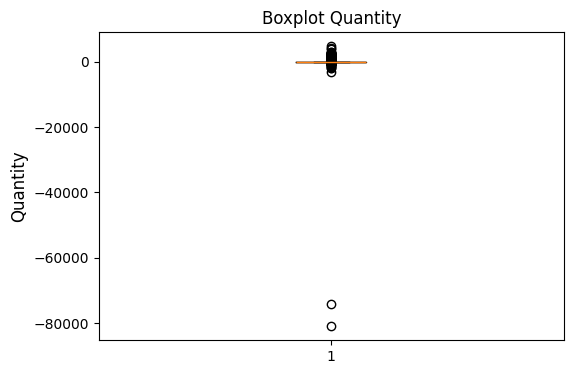

In [ ]:
#Mengecek outliers menggunakan boxplot
plt.figure(figsize=(6,4))
plt.boxplot(df['quantity'])
plt.title('Boxplot Quantity',fontsize=12)
plt.ylabel('Quantity',fontsize=12)
plt.show()

In [ ]:
df_outliers_ekstrem = df[df['quantity'] > 70000]
kolom_analisis = ['invoice_code', 'stock_code', 'description',
                  'quantity', 'price_rupiah', 'revenue',
                  'customer_id', 'date']
display(df_outliers_ekstrem[kolom_analisis])

,invoice_code,stock_code,description,quantity,price_rupiah,revenue,customer_id,date


#Feature Engineering

##Price Rupiah

In [ ]:
# Mengalikan kolom price dengan 8790 untuk membuat kolom price_rupiah
df['price_rupiah'] = df['price'] * 8790

display(df[['price', 'price_rupiah']].head())

,price,price_rupiah
0,2.55,22414.5
1,3.39,29798.1
2,2.75,24172.5
3,3.39,29798.1
4,3.39,29798.1


##Date, Month, Year, Day of Week, Is Weekend, Hour Transaction

In [ ]:
df["month"] = df["order_date"].dt.month
df["date"] = df["order_date"].dt.day
df["year"] = df["order_date"].dt.year
df["day_of_week"] = df["order_date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["hour_transaction"] = df["order_date"].dt.hour

In [ ]:
df[[
    "order_date",
    "month",
    "date",
    "year",
    "day_of_week",
    "is_weekend",
    "hour_transaction"
]].head()

,order_date,month,date,year,day_of_week,is_weekend,hour_transaction
0,2010-12-01 08:26:00,12,1,2010,2,0,8
1,2010-12-01 08:26:00,12,1,2010,2,0,8
2,2010-12-01 08:26:00,12,1,2010,2,0,8
3,2010-12-01 08:26:00,12,1,2010,2,0,8
4,2010-12-01 08:26:00,12,1,2010,2,0,8


##Revenue

In [ ]:
df['revenue'] = df['price_rupiah'] * df['quantity']

In [ ]:
df['revenue'].head()

,revenue
0,134487.0
1,178788.6
2,193380.0
3,178788.6
4,178788.6


##Quantity Category

In [ ]:
# Tentukan batas angka (bins) untuk setiap kategori
# Batas: 0-10 (Small), 11-50 (Medium), 51-500 (Large)
# 501 ke atas hingga tak terhingga (Wholesaler)
batas_angka = [0, 10, 50, 500, float('inf')]

# Tentukan label teks untuk masing-masing kelompok tersebut
label_kategori = ['Small', 'Medium', 'Large', 'Wholesaler']

# Isi kolom quantity_category menggunakan fungsi pd.cut()
# errors='coerce' (abaikan nilai negatif) -> tidak error saat pemotongan angka
df['quantity_category'] = pd.cut(df[
    'quantity'],bins=batas_angka, labels=label_kategori)

# Transaksi pembatalan (quantity < 0) diberi label khusus 'Canceled/Return'
df['quantity_category'] = df['quantity_category'].astype(str)
df.loc[df['quantity'] < 0, 'quantity_category'] = 'Canceled/Return'

# Hitung berapa banyak transaksi yang masuk ke tiap-tiap kategori
print("Distribusi Jumlah Transaksi per Kategori:")
print(df['quantity_category'].value_counts())

# Tampilkan sampel acak untuk melihat hasil pemetaan
display(df[['quantity', 'quantity_category']].sample(10, random_state=42))

Distribusi Jumlah Transaksi per Kategori:
quantity_category
Small              385224
Medium             118284
Large               11313
Canceled/Return      3305
Wholesaler            378
Name: count, dtype: int64


,quantity,quantity_category
412349,1,Small
295811,2,Small
14856,4,Small
284437,1440,Wholesaler
296788,2,Small
468640,2,Small
291132,11,Medium
416596,1,Small
165540,24,Medium
35428,1,Small


##Rename Description

In [ ]:
df = df.rename(columns={'description': 'nama_produk'})

In [ ]:
df.head(5)

,invoice_code,stock_code,nama_produk,quantity,order_date,price,unit,customer_id,country,price_rupiah,...,month,year,revenue,day_of_week,is_weekend,hour_transaction,quantity_category,segment_rfm,basket_size,product_category
0,536365,90220,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,dollar,17850,United Kingdom,22414.5,...,12,2010,134487.0,2,0,8,Small,NaN,NaN,NaN
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,dollar,17850,United Kingdom,29798.1,...,12,2010,178788.6,2,0,8,Small,NaN,NaN,NaN
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,dollar,17850,United Kingdom,24172.5,...,12,2010,193380.0,2,0,8,Small,NaN,NaN,NaN
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,dollar,17850,United Kingdom,29798.1,...,12,2010,178788.6,2,0,8,Small,NaN,NaN,NaN
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART,6,2010-12-01 08:26:00,3.39,dollar,17850,United Kingdom,29798.1,...,12,2010,178788.6,2,0,8,Small,NaN,NaN,NaN


## Mengubah Basket Size = 1


In [ ]:
df['basket_size'] = 1

In [ ]:
# Mengubah tipe data kolom basket_size menjadi integer
df['basket_size'] = df['basket_size'].astype(int)

## Mengisi Segmen RFM

In [ ]:
# Pastikan kolom tanggal di tabel utamamu sudah bertipe datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# HITUNG SEGMENTASI PER CUSTOMER
# Filter data valid
df_filtered = df[
    (df['customer_id'].notnull()) &
    (df['order_date'] <= '2012-01-01') &
    (~df['invoice_code'].str.startswith('C', na=False)) &
    (df['quantity'] > 0)
].copy()

snapshot_date = pd.to_datetime('2012-01-01')

# Agregasi dasar RFM
rfm_cust = df_filtered.groupby('customer_id').agg(
    recency=('order_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('invoice_code', 'nunique'),
    monetary=('revenue', 'sum')
).reset_index()

# Scoring 1-5 menggunakan pd.qcut
rfm_cust['r_score'] = pd.qcut(rfm_cust['recency'], q=5, labels=[
    5, 4, 3, 2, 1]).astype(str)
rfm_cust['f_score'] = pd.qcut(rfm_cust['frequency'].rank(
    method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(str)
rfm_cust['m_score'] = pd.qcut(rfm_cust['monetary'], q=5, labels=[
    1, 2, 3, 4, 5]).astype(str)
rfm_cust['rfm_cell'] = rfm_cust['r_score'] + rfm_cust[
    'f_score'] + rfm_cust['m_score']

# Dictionary kelompok Segmen RFM
segment_map = {
    r'^(555|554|544|545|454|455|445)$': 'Champions',
    r'^(543|444|435|355|354|345|344|335)$': 'Loyal',
    r'^(553|551|552|541|542|533|532|531|452|451|442|441|431|453|433|432|423|353|352|351|342|341|333|323)$': 'Potential Loyalist',
    r'^(512|511|422|421|412|411|311)$': 'New Customers',
    r'^(525|524|523|522|521|515|514|513|425|424|413|414|415|315|314|313)$': 'Promising',
    r'^(535|534|443|434|343|334|325|324)$': 'Need Attention',
    r'^(331|321|312|221|213|231|241|251)$': 'About to Sleep',
    r'^(155|154|144|214|215|115|114|113)$': 'Cannot Lose Them',
    r'^(255|254|245|244|253|252|243|242|235|234|225|224|153|152|145|143|142|135|134|133|125|124)$': 'At Risk',
    r'^(332|322|233|232|223|222|132|123|122|212|211)$': 'Hibernating'
}

# Terapkan mapping segmen teks
rfm_cust['segment_name'] = rfm_cust['rfm_cell'].replace(segment_map, regex=True)
rfm_cust['segment_name'] = rfm_cust['segment_name'].apply(lambda x: x if x in segment_map.values() else 'Lost')

# UPDATE / MASUKKAN HASIL KE KOLOM 'Segmen RFM'
# Kita buat Series mapping berbasis customer_id
mapping_series = rfm_cust.set_index('customer_id')['segment_name']

# Isi kolom 'Segmen RFM' di dataframe utama menggunakan fungsi .map()
df['segment_rfm'] = df['customer_id'].map(mapping_series)

# Beri nilai 'Lost' atau 'Non-Customer' jika ada baris yang tidak kebagian segmen (misal customer_id-nya NULL)
df['segment_rfm'] = df['segment_rfm'].fillna('Lost')

# Cek apakah kolom sudah terisi dengan benar
print(df[['customer_id', 'segment_rfm']].head(10))

    customer_id       segment_rfm
0         17850  Cannot Lose Them
1         17850  Cannot Lose Them
2         17850  Cannot Lose Them
3         17850  Cannot Lose Them
4         17850  Cannot Lose Them
5         17850  Cannot Lose Them
6         17850  Cannot Lose Them
7         17850  Cannot Lose Them
9         13047         Champions
10        13047         Champions


In [ ]:
# Mengubah tipe data kolom menjadi string
df['segment_rfm'] = df['segment_rfm'].astype(str)

# Mengisi Product Category

In [ ]:
df['nama_produk_clean'] = df['nama_produk'].fillna('').astype(
    str).str.strip().str.upper()
df['stock_code_str'] = df['stock_code'].fillna('').astype(str)

# Kondisi : kiri , hasil : kanan
conditions = [
    # Voucher & Special Clearance
    df['stock_code_str'].str.startswith('DCGS') | df[
        'stock_code_str'].str.startswith('GIFT'),

    # Gifts & Party Supplies (Berdasarkan Kata Kunci)
    df['nama_produk_clean'].str.contains('BALLOON|PARTY', regex=True),

    # Seasonal & Christmas (Berdasarkan Kata Kunci)
    df['nama_produk_clean'].str.contains('CHRISTMAS|XMAS', regex=True),

    # Bags & Fashion Accessories (Berdasarkan Kata Kunci)
    df['nama_produk_clean'].str.contains('BAG', regex=True),

    # Filter berdasarkan awalan angka stock_code (LIKE '1%', dst)
    df['stock_code_str'].str.startswith('1'),
    df['stock_code_str'].str.startswith('2'),
    df['stock_code_str'].str.startswith('3'),
    df['stock_code_str'].str.startswith('4'),
    df['stock_code_str'].str.startswith('5'),
    df['stock_code_str'].str.startswith('6'),
    df['stock_code_str'].str.startswith('7'),
    df['stock_code_str'].str.startswith('8'),
    df['stock_code_str'].str.startswith('9')
]

choices = [
    'Vouchers & Special Clearance',
    'Gifts & Party Supplies',
    'Seasonal & Christmas',
    'Bags & Fashion Accessories',
    'Stationery & Paper Goods',
    'Home Decor & Kitchenware',
    'Gifts & Party Supplies',
    'Bags & Fashion Accessories',
    'Luggage, Travel, & Toys',
    'Crafts & Hardware',
    'Textiles & Soft Furnishings',
    'Seasonal & Christmas',
    'Premium Gifts & Jewelry'
]

# EKSEKUSI DAN SIMPAN KE KOLOM product_category
# default='General Merchandise' bertindak sebagai ELSE di SQL
df['product_category'] = np.select(
    conditions, choices, default='General Merchandise')

# Hapus kolom temporary yang tadi dibuat agar dataset tetap bersih
df = df.drop(columns=['nama_produk_clean', 'stock_code_str'])

# Cek hasil akhir untuk memastikan tidak ada yang kosong
print(df['product_category'].value_counts())

product_category
Home Decor & Kitchenware        350113
Seasonal & Christmas             76549
Bags & Fashion Accessories       57087
Gifts & Party Supplies           13472
Premium Gifts & Jewelry           7151
Stationery & Paper Goods          6900
Textiles & Soft Furnishings       6479
Luggage, Travel, & Toys            621
Crafts & Hardware                   65
Vouchers & Special Clearance        64
General Merchandise                  3
Name: count, dtype: int64


In [ ]:
# Mengubah tipe data kolom product_category menjadi integer
df['product_category'] = df['product_category'].astype(str)

In [ ]:
df

,invoice_code,stock_code,nama_produk,quantity,order_date,price,unit,customer_id,country,price_rupiah,...,month,year,revenue,day_of_week,is_weekend,hour_transaction,quantity_category,segment_rfm,basket_size,product_category
0,536365,90220,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,dollar,17850,United Kingdom,22414.5,...,12,2010,134487.0,2,0,8,Small,Cannot Lose Them,1,Premium Gifts & Jewelry
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,dollar,17850,United Kingdom,29798.1,...,12,2010,178788.6,2,0,8,Small,Cannot Lose Them,1,Textiles & Soft Furnishings
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,dollar,17850,United Kingdom,24172.5,...,12,2010,193380.0,2,0,8,Small,Cannot Lose Them,1,Seasonal & Christmas
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,dollar,17850,United Kingdom,29798.1,...,12,2010,178788.6,2,0,8,Small,Cannot Lose Them,1,Seasonal & Christmas
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART,6,2010-12-01 08:26:00,3.39,dollar,17850,United Kingdom,29798.1,...,12,2010,178788.6,2,0,8,Small,Cannot Lose Them,1,Seasonal & Christmas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,dollar,12680,France,7471.5,...,12,2011,89658.0,4,0,12,Medium,Champions,1,Home Decor & Kitchenware
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,dollar,12680,France,18459.0,...,12,2011,110754.0,4,0,12,Small,Champions,1,Home Decor & Kitchenware
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,dollar,12680,France,36478.5,...,12,2011,145914.0,4,0,12,Small,Champions,1,Home Decor & Kitchenware
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,dollar,12680,France,36478.5,...,12,2011,145914.0,4,0,12,Small,Champions,1,Home Decor & Kitchenware


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 518504 entries, 0 to 541908
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   invoice_code       518504 non-null  object        
 1   stock_code         518504 non-null  object        
 2   nama_produk        518504 non-null  object        
 3   quantity           518504 non-null  int64         
 4   order_date         518504 non-null  datetime64[ns]
 5   price              518504 non-null  float64       
 6   unit               518504 non-null  object        
 7   customer_id        518504 non-null  int64         
 8   country            518504 non-null  object        
 9   price_rupiah       518504 non-null  float64       
 10  date               518504 non-null  int32         
 11  month              518504 non-null  int32         
 12  year               518504 non-null  int32         
 13  revenue            518504 non-null  float64      

#Mengimport Data yang Sudah Di-Cleaning ke SQL

In [ ]:
#Mengimport data setelah di cleaning ke SQL
df.to_sql('online_retail',con=engine,schema='public',if_exists='replace',index=False)

In [ ]:
df.to_excel('online_retail.xlsx')

# Import Library

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings
warnings.simplefilter("ignore", DeprecationWarning)

# Content Based

In [ ]:
# 1. Saring data dari dataframe aktif (hapus transaksi 'C' & qty <0)
df_filtered = df[
    (~df['invoice_code'].str.startswith('C', na=False)) &
    (df['quantity'] > 0)
].copy()

# 2. Potong data menggunakan .iloc untuk mengambil 250.000 baris pertama
# Jika total data < 25.656 -> ambil seluruh data
df_copy1 = df_filtered.iloc[:25656].copy()

# Cek jumlah baris sebelum dan sesudah dipotong
print("Jumlah baris setelah disaring awal:", len(df_filtered))
print("Jumlah baris setelah dipotong dengan iloc:", len(df_copy1))

Jumlah baris setelah disaring awal: 515199
Jumlah baris setelah dipotong dengan iloc: 25656


In [ ]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df_copy1['product_category'])
cosine_sim = cosine_similarity(tfidf_matrix)

In [ ]:
indices = pd.Series(df_copy1.index, index=df_copy1[
    'nama_produk']).drop_duplicates()

In [ ]:
df_unique_products = df_copy1[['stock_code', 'nama_produk',
                               'product_category']].drop_duplicates(subset=[
                                   'stock_code']).reset_index(drop=True)

indices = pd.Series(df_unique_products.index, index=
                    df_unique_products['nama_produk']).to_dict()

def recommend_df_copy1(nama_produk, n=10):
    idx = indices[nama_produk]
    sim_scores = list(
        enumerate(cosine_sim[idx])
    )
    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )
    sim_scores = sim_scores[1:n+1]
    product_indices = [i[0] for i in sim_scores]
    similarity_scores = [i[1] for i in sim_scores]
    recommendations = df_copy1[
        ["nama_produk", "product_category"]
    ].iloc[product_indices].copy()
    recommendations["cosine_similarity"] = similarity_scores
    return recommendations

In [ ]:
recommend_df_copy1("RED WOOLLY HOTTIE WHITE HEART")

,nama_produk,product_category,cosine_similarity
3,KNITTED UNION FLAG HOT WATER BOTTLE,Seasonal & Christmas,1.0
4,RED WOOLLY HOTTIE WHITE HEART,Seasonal & Christmas,1.0
13,ASSORTED COLOUR BIRD ORNAMENT,Seasonal & Christmas,1.0
18,BOX OF 6 ASSORTED COLOUR TEASPOONS,Seasonal & Christmas,1.0
46,PAPER CHAIN KIT 50'S CHRISTMAS,Seasonal & Christmas,1.0
51,CREAM CUPID HEARTS COAT HANGER,Seasonal & Christmas,1.0
58,WOOD S/3 CABINET ANT WHITE FINISH,Seasonal & Christmas,1.0
59,WOODEN PICTURE FRAME WHITE FINISH,Seasonal & Christmas,1.0
60,WOODEN FRAME ANTIQUE WHITE,Seasonal & Christmas,1.0
61,KNITTED UNION FLAG HOT WATER BOTTLE,Seasonal & Christmas,1.0


# Collaborative Filtering

In [ ]:
# 1. Saring data dari dataframe aktif (hapus transaksi 'C' & qty < 0)
df_filtered = df[
    (~df['invoice_code'].str.startswith('C', na=False)) &
    (df['quantity'] > 0)
].copy()

# 2. Potong data menggunakan .iloc untuk mengambil 250.000 baris pertama
# Jika total data < 100.000 -> mengambil seluruh data yang tersedia
df_copy2 = df_filtered.iloc[:100000].copy()

# Cek jumlah baris sebelum dan sesudah dipotong
print("Jumlah baris setelah disaring awal:", len(df_filtered))
print("Jumlah baris setelah dipotong dengan iloc:", len(df_copy2))

Jumlah baris setelah disaring awal: 515199
Jumlah baris setelah dipotong dengan iloc: 100000


In [ ]:
user_item_matrix = df_copy2.pivot_table(
    index='customer_id',
    columns='nama_produk',
    values='basket_size',  # Menggunakan kolom basket_size yang bernilai 1
    fill_value=0           # Produk yang tidak dibeli diberi nilai 0
)

# Cek ukuran matriks yang terbentuk
print("Ukuran Matriks (Total Customer, Totak Produk):", user_item_matrix.shape)

Ukuran Matriks (Total Customer, Totak Produk): (36482, 2977)


In [ ]:
# Menghitung korelasi antar-produk menggunakan metode Pearson
product_corr = user_item_matrix.corr(method='pearson')

In [ ]:
# Tampilkan beberapa baris dan kolom pertama dari matriks korelasi
product_corr.iloc[:5]

nama_produk,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE POSY,...,ZINC FINISH 15CM PLANTER POTS,ZINC FOLKART SLEIGH BELLS,ZINC HEART LATTICE 2 WALL PLANTER,ZINC HEART LATTICE CHARGER LARGE,ZINC HEART LATTICE CHARGER SMALL,ZINC HEART LATTICE T-LIGHT HOLDER,ZINC HEART LATTICE TRAY OVAL,ZINC METAL HEART DECORATION,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK
nama_produk,,,,,,,,,,,,,,,,,,,,,
10 COLOUR SPACEBOY PEN,1.000000,0.058373,-0.001041,-0.001105,-0.001258,-0.001361,0.046406,0.076309,0.082733,-0.000705,...,-0.001145,-0.000823,-0.000301,-0.000521,-0.000301,-0.001041,-0.000301,0.035702,-0.000601,0.033973
12 COLOURED PARTY BALLOONS,0.058373,1.000000,-0.000586,-0.000621,-0.000707,-0.000766,0.027524,0.045239,0.049037,0.138003,...,-0.000644,-0.000463,-0.000169,-0.000293,-0.000169,-0.000586,-0.000169,0.021200,-0.000338,-0.000871
12 DAISY PEGS IN WOOD BOX,-0.001041,-0.000586,1.000000,0.038613,0.033736,-0.000861,0.100314,0.101939,0.087987,0.061130,...,0.037209,-0.000520,-0.000190,-0.000329,-0.000190,-0.000658,-0.000190,0.038533,-0.000380,-0.000979
12 EGG HOUSE PAINTED WOOD,-0.001105,-0.000621,0.038613,1.000000,0.031714,-0.000913,-0.001150,-0.001412,-0.001307,-0.000473,...,0.034997,-0.000552,-0.000202,-0.000349,-0.000202,-0.000698,-0.000202,-0.001462,0.135745,0.025426
12 IVORY ROSE PEG PLACE SETTINGS,-0.001258,-0.000707,0.033736,0.031714,1.000000,0.078238,0.061674,0.083921,0.072403,-0.000538,...,0.061958,-0.000628,0.119354,-0.000397,-0.000229,-0.000795,-0.000229,0.064445,0.059338,0.045310


In [ ]:
def recommend_retail_cf(target_nama_produk, n=10):
    # Standardisasi teks input
    target_nama_produk = str(target_nama_produk).strip().upper()

    # Ambil baris korelasi untuk produk yang dicari
    if target_nama_produk not in product_corr.columns:
        return pd.DataFrame({"nama_produk": [f"Produk '{
            target_nama_produk}' tidak ditemukan di matriks CF"]})

    similar_products = (
        product_corr[target_nama_produk]
        .sort_values(ascending=False)
        .iloc[1:n+1]
    )

    # Masukkan ke DataFrame awal
    result = pd.DataFrame({
        'nama_produk': similar_products.index,
        'pearson_correlation': similar_products.values
    })

    # Ambil info master produk anti-tertukar
    # Kita mapping manual menggunakan dictionary berdasarkan df_copy2 asli
    mapping_stock = dict(zip(df_copy2['nama_produk'], df_copy2['stock_code']))
    mapping_cat = dict(zip(df_copy2['nama_produk'],
                           df_copy2['product_category']))

    # Isi kolom pelengkap berdasarkan dictionary mapping teks nama produk
    result['stock_code'] = result['nama_produk'].map(mapping_stock)
    result['product_category'] = result['nama_produk'].map(mapping_cat)

    # Buat alasan rekomendasi otomatis
    result['recommendation_reason'] = (
        'Pelanggan yang membeli produk "' + str(target_nama_produk) +
        '" juga cenderung membeli produk ini secara bersamaan.'
    )

    # Susun susunan kolom agar rapi dan tidak tertukar
    return result[
        [
            'nama_produk',
            'stock_code',
            'product_category',
            'pearson_correlation',
            'recommendation_reason'
        ]
    ]

# FP Growth

In [ ]:
# Filter data: Hapus transaksi yang di-cancelled ('C') dan kuantitas negatif
df_valid = df[
    (~df['invoice_code'].str.startswith('C', na=False)) &
    (df['quantity'] > 0)
].copy()

# Grouping
df_rank_kategori = df_valid.groupby('product_category')[
    'revenue'].sum().reset_index()

# Peringkat berdasarkan total revenue terbesar
df_rank_kategori['rank_by_revenue'] = (
    df_rank_kategori['revenue']
    .rank(ascending=False, method='dense')
    .astype(int)
)

# Urutkan DataFrame baru ini berdasarkan ranking teratas
df_rank_kategori = df_rank_kategori.sort_values(
    by='rank_by_revenue').reset_index(drop=True)

# Tampilkan DataFrame
df_rank_kategori

,product_category,revenue,rank_by_revenue
0,Home Decor & Kitchenware,5.665722e+10,1
1,Seasonal & Christmas,1.160705e+10,2
2,Bags & Fashion Accessories,1.077128e+10,3
3,Gifts & Party Supplies,2.195225e+09,4
4,Textiles & Soft Furnishings,1.403375e+09,5
5,Premium Gifts & Jewelry,1.322025e+09,6
6,Stationery & Paper Goods,1.054988e+09,7
7,"Luggage, Travel, & Toys",5.467907e+07,8
8,Crafts & Hardware,5.031018e+07,9
9,Vouchers & Special Clearance,9.530645e+06,10


In [ ]:
# Buat df_copy bersih dari data cancelled
df_copy3 = df[
    (~df['invoice_code'].str.startswith('C', na=False)) &
    (df['quantity'] > 0)
].iloc[:250000].copy()

In [ ]:
# Gabungkan df_copy3 dengan df_rank_category untuk bawa kolom 'rank_by_revenue'
df_merge_rank = df_copy3.merge(
    df_rank_kategori[['product_category', 'rank_by_revenue']],
    on='product_category',
    how='left'
)

In [ ]:
df_merge_rank

,invoice_code,stock_code,nama_produk,quantity,order_date,price,unit,customer_id,country,price_rupiah,...,year,revenue,day_of_week,is_weekend,hour_transaction,quantity_category,segment_rfm,basket_size,product_category,rank_by_revenue
0,536365,90220,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,dollar,17850,United Kingdom,22414.5,...,2010,134487.0,2,0,8,Small,Cannot Lose Them,1,Premium Gifts & Jewelry,6
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,dollar,17850,United Kingdom,29798.1,...,2010,178788.6,2,0,8,Small,Cannot Lose Them,1,Textiles & Soft Furnishings,5
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,dollar,17850,United Kingdom,24172.5,...,2010,193380.0,2,0,8,Small,Cannot Lose Them,1,Seasonal & Christmas,2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,dollar,17850,United Kingdom,29798.1,...,2010,178788.6,2,0,8,Small,Cannot Lose Them,1,Seasonal & Christmas,2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART,6,2010-12-01 08:26:00,3.39,dollar,17850,United Kingdom,29798.1,...,2010,178788.6,2,0,8,Small,Cannot Lose Them,1,Seasonal & Christmas,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,560024,47566B,TEA TIME PARTY BUNTING,2,2011-07-14 13:00:00,4.95,dollar,15005,United Kingdom,43510.5,...,2011,87021.0,3,0,13,Small,Champions,1,Gifts & Party Supplies,4
249996,560024,23298,SPOTTY BUNTING,2,2011-07-14 13:00:00,4.95,dollar,15005,United Kingdom,43510.5,...,2011,87021.0,3,0,13,Small,Champions,1,Home Decor & Kitchenware,1
249997,560024,22197,POPCORN HOLDER,10,2011-07-14 13:00:00,0.85,dollar,15005,United Kingdom,7471.5,...,2011,74715.0,3,0,13,Small,Champions,1,Home Decor & Kitchenware,1
249998,560024,82486,WOOD S/3 CABINET ANT WHITE FINISH,2,2011-07-14 13:00:00,8.95,dollar,15005,United Kingdom,78670.5,...,2011,157341.0,3,0,13,Small,Champions,1,Seasonal & Christmas,2


In [ ]:
basket_data = df_merge_rank[df_merge_rank['rank_by_revenue'] <= 5].copy()
basket_ranking = df_merge_rank.pivot_table(
    index='invoice_code',
    columns='product_category',
    values='rank_by_revenue',
    aggfunc='count',
    fill_value=0
)

In [ ]:
basket_ranking

product_category,Bags & Fashion Accessories,Crafts & Hardware,General Merchandise,Gifts & Party Supplies,Home Decor & Kitchenware,"Luggage, Travel, & Toys",Premium Gifts & Jewelry,Seasonal & Christmas,Stationery & Paper Goods,Textiles & Soft Furnishings,Vouchers & Special Clearance
invoice_code,,,,,,,,,,,
536365,0,0,0,0,2,0,1,3,0,1,0
536366,0,0,0,0,1,0,0,0,0,0,0
536367,1,0,0,0,9,0,0,2,0,0,0
536368,0,0,0,0,4,0,0,0,0,0,0
536369,0,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
559993,0,0,0,1,13,0,0,8,0,0,0
560010,6,0,0,0,13,0,0,0,0,0,0
560018,1,0,0,2,51,0,0,0,3,2,0


In [ ]:
basket = basket_ranking.fillna(0)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

/tmp/ipykernel_5848/2743305005.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


In [ ]:
basket

product_category,Bags & Fashion Accessories,Crafts & Hardware,General Merchandise,Gifts & Party Supplies,Home Decor & Kitchenware,"Luggage, Travel, & Toys",Premium Gifts & Jewelry,Seasonal & Christmas,Stationery & Paper Goods,Textiles & Soft Furnishings,Vouchers & Special Clearance
invoice_code,,,,,,,,,,,
536365,0,0,0,0,1,0,1,1,0,1,0
536366,0,0,0,0,1,0,0,0,0,0,0
536367,1,0,0,0,1,0,0,1,0,0,0
536368,0,0,0,0,1,0,0,0,0,0,0
536369,0,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
559993,0,0,0,1,1,0,0,1,0,0,0
560010,1,0,0,0,1,0,0,0,0,0,0
560018,1,0,0,1,1,0,0,0,1,1,0


In [ ]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Jalankan FP-Growth untuk mencari Frequent Itemsets
frequent_itemsets = fpgrowth(basket, min_support=0.005, use_colnames=True)

# Ambil aturan asosiasi dengan lift score minimal 1
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

In [ ]:
# Ambil data master produk unik dari df_copy
df_unique_master = df_copy3[['stock_code',
                             'nama_produk']].drop_duplicates(
                                 subset=['stock_code'])

# Buat dictionary pemetaan kode ke nama
product_dict = dict(zip(df_unique_master['stock_code'],
                        df_unique_master['nama_produk']))

# Fungsi penterjemah frozenset kode menjadi teks nama produk
def convert_names(itemset):
    return [product_dict.get(i, str(i)) for i in itemset]

In [ ]:
# Terjemahkan kode produk antecedents dan consequents menjadi nama asli
rules["antecedent_products"] = rules["antecedents"].apply(convert_names)
rules["consequent_products"] = rules["consequents"].apply(convert_names)

# Ambil kolom penting untuk dianalisis
result = rules[
    [
        "antecedent_products",
        "consequent_products",
        "support",
        "confidence",
        "lift"
    ]
]

# Gabungan looping otomatis untuk menyaring strong rules
# Menentukan target awal batasan nilai
target_confidence = 0.55
target_lift = 1.0
min_rules_wanted = 5  #minimal aturan diinginkan agar mesin rekomendasi bekerja

# Looping terus berjalan menurunkan confidence jika hasil saringan masih kosong
while target_confidence >= 0.05:  # Batas toleransi paling rendah (5%)
    strong_rules = result[
        (result["confidence"] >= target_confidence) &
        (result["lift"] >= target_lift)
    ].copy()

    # Jika jumlah aturan lolos sudah memenuhi target minimum, hentikan looping
    if len(strong_rules) >= min_rules_wanted:
        print(f"Looping Berhasil Dihentikan!")
        print(f"-> Batas Confidence optimal ditemukan pada tingkat: {target_confidence:.2f}")
        print(f"-> Batas Lift optimal ditemukan pada tingkat: {target_lift:.1f}")
        break

    # Jika masih kosong atau kurang, turunkan confidence sebanyak 0.05 (5%) untuk loop berikutnya
    target_confidence -= 0.05

# Tampilkan hasil akhir setelah looping selesai
print(f"Jumlah aturan kuat untuk rekomendasi: {len(strong_rules)} aturan.")

# Mengurutkan berdasarkan lift score tertinggi agar kualitas rekomendasi paling bagus berada di atas
strong_rules = strong_rules.sort_values(by="lift", ascending=False).reset_index(drop=True)
strong_rules.head(10)

Looping Berhasil Dihentikan!
-> Batas Confidence optimal ditemukan pada tingkat: 0.55
-> Batas Lift optimal ditemukan pada tingkat: 1.0
Jumlah aturan kuat untuk rekomendasi: 1351 aturan.


,antecedent_products,consequent_products,support,confidence,lift
0,"[Seasonal & Christmas, Luggage, Travel, & Toys...","[Textiles & Soft Furnishings, Bags & Fashion A...",0.00526,0.552083,8.816710
1,"[Seasonal & Christmas, Luggage, Travel, & Toys...","[Textiles & Soft Furnishings, Bags & Fashion A...",0.00526,0.552083,8.802759
2,"[Home Decor & Kitchenware, Seasonal & Christma...","[Textiles & Soft Furnishings, Bags & Fashion A...",0.00526,0.552083,8.802759
3,"[Bags & Fashion Accessories, Luggage, Travel, ...","[Textiles & Soft Furnishings, Stationery & Pap...",0.00526,0.595506,8.646845
4,"[Bags & Fashion Accessories, Home Decor & Kitc...","[Textiles & Soft Furnishings, Stationery & Pap...",0.00526,0.595506,8.634403
5,"[Bags & Fashion Accessories, Luggage, Travel, ...","[Textiles & Soft Furnishings, Stationery & Pap...",0.00526,0.595506,8.634403
6,"[Bags & Fashion Accessories, Seasonal & Christ...","[Textiles & Soft Furnishings, Stationery & Pap...",0.00526,0.616279,8.414965
7,"[Bags & Fashion Accessories, Seasonal & Christ...","[Textiles & Soft Furnishings, Stationery & Pap...",0.00526,0.616279,8.369601
8,"[Bags & Fashion Accessories, Seasonal & Christ...","[Textiles & Soft Furnishings, Stationery & Pap...",0.00526,0.616279,8.369601
9,"[Bags & Fashion Accessories, Luggage, Travel, ...","[Textiles & Soft Furnishings, Stationery & Pap...",0.00526,0.595506,8.131315


In [ ]:
def recommend_retail_fpgrowth(product_name, n=20):
    # Standardisasi input nama produk (Hapus spasi ujung & ubah ke kapital)
    product_name = str(product_name).strip().upper()

    # Cek apakah tabel strong_rules hasil FP-Growth ada isinya
    if 'strong_rules' not in globals() or strong_rules.empty:
        return "Tabel 'strong_rules' kosong. Selesaikan pencarian aturan asosiasi terlebih dahulu."

    # Cari nama produk di dalam kolom list 'antecedent_products'
    # Gunakan pembersihan spasi dalam list antecedent agar pencarian akurat
    recommendations = strong_rules[
        strong_rules["antecedent_products"].apply(lambda x: product_name in [
            str(i).strip().upper() for i in x])].copy()

    # Jika dari aturan asosiasi memang tidak ditemukan pasangan untuk produk ini
    if recommendations.empty:
        return f"Tidak ada rekomendasi pola belanja yang kuat untuk produk '{product_name}'."

    # Ambil produk konsekuen pertama sebagai barang rekomendasi
    recommendations["recommended_product"] = (
        recommendations["consequent_products"]
        .apply(lambda x: str(x[0]).strip().upper() if len(x) > 0 else None)
    )

    # Ambil data master produk menggunakan variabel yang aktif (df_copy3)
    # Gunakan df_copy3 karena ini data transaksi aktif yang sudah dipotong
    if 'df_copy3' in globals():
        df_active = df_copy3
    elif 'df_copy2' in globals():
        df_active = df_copy2
    else:
        df_active = df_valid # Backup jika angka copy tertukar

    # Buat kamus (mapping dictionary) dari data aktif untuk ditarik kategorinya
    product_to_category = dict(zip(df_active['nama_produk'].str.strip().str.upper(), df_active['product_category']))

    # Petakan langsung kategori produk berdasarkan nama produk rekomendasinya
    recommendations["product_category"] = recommendations["recommended_product"].map(product_to_category)

    # Merge dengan tabel revenue
    # Buat kamus untuk memetakan peringkat revenue kategori
    category_to_rank = dict(zip(df_rank_kategori['product_category'],
                                df_rank_kategori['rank_by_revenue']))

    recommendations["rank_by_revenue"] = recommendations[
        "product_category"].map(category_to_rank)

    # Isi alasan rekomendasi market basket
    recommendations["recommendation_reason"] = "Frequently bought together"

    # Urutkan berdasarkan kategori terlaris, baru berdasarkan lift score
    recommendations = (
        recommendations
        .sort_values(by=["rank_by_revenue", "lift"], ascending=[True, False])
        .drop_duplicates(subset=['recommended_product'])
    )

    # Fill NaN ranking dengan angka besar jika ada kategori baru tidak masuk ranking
    recommendations["rank_by_revenue"] = recommendations[
        "rank_by_revenue"].fillna(999).astype(int)

    # 7. Kembalikan susunan kolom akhir yang bersih
    return recommendations[
        [
            "recommended_product",
            "product_category",
            "rank_by_revenue",
            "support",
            "confidence",
            "lift",
            "recommendation_reason"
        ]
    ].head(n).reset_index(drop=True)

# Perbandingan

In [ ]:
def compare_recommendations(nama_produk, n=10):
    nama_produk = str(nama_produk).strip().upper()

    # Ambil hasil Content Based
    try:
        cb = recommend_df_copy1(nama_produk)
        if isinstance(cb, pd.DataFrame) and not cb.empty:
            cb_list = cb.iloc[:, 0].reset_index(drop=True)
        else:
            cb_list = pd.Series([cb] if cb else ["-"])
    except Exception as e:
        cb_list = pd.Series([f"Error CB"])

    # Ambil hasul Collaborative Filtering
    try:
        cf = recommend_retail_cf(nama_produk)
        if isinstance(cf, pd.DataFrame) and not cf.empty:
            cf_list = cf.iloc[:, 0].reset_index(drop=True)
        else:
            cf_list = pd.Series([cf] if cf else ["-"])
    except Exception as e:
        cf_list = pd.Series([f"Error CF"])

    # Ambil hasil FP-Growth
    try:
        fp = recommend_retail_fpgrowth(nama_produk)
        if isinstance(fp, pd.DataFrame) and not fp.empty:
            fp_list = fp.iloc[:, 0].reset_index(drop=True)
        else:
            fp_list = pd.Series([fp] if fp else ["-"])
    except Exception as e:
        fp_list = pd.Series([f"Error FP"])

    # Gabungkan ke dataframe utama
    result = pd.DataFrame({
        "Content_Based": cb_list,
        "Collaborative_Filtering": cf_list,
        "FP_Growth": fp_list
    })

    # Potong sesuai jumlah n dan isi baris kosong dengan strip
    return result.fillna("-").head(n)

In [ ]:
compare_recommendations("RED WOOLLY HOTTIE WHITE HEART")

,Content_Based,Collaborative_Filtering,FP_Growth
0,KNITTED UNION FLAG HOT WATER BOTTLE,WHITE SKULL HOT WATER BOTTLE,Tidak ada rekomendasi pola belanja yang kuat u...
1,RED WOOLLY HOTTIE WHITE HEART,SCOTTIE DOG HOT WATER BOTTLE,-
2,ASSORTED COLOUR BIRD ORNAMENT,KNITTED UNION FLAG HOT WATER BOTTLE,-
3,BOX OF 6 ASSORTED COLOUR TEASPOONS,RETROSPOT HEART HOT WATER BOTTLE,-
4,PAPER CHAIN KIT 50'S CHRISTMAS,CHOCOLATE HOT WATER BOTTLE,-
5,CREAM CUPID HEARTS COAT HANGER,HOT WATER BOTTLE BABUSHKA,-
6,WOOD S/3 CABINET ANT WHITE FINISH,HAND WARMER SCOTTY DOG DESIGN,-
7,WOODEN PICTURE FRAME WHITE FINISH,POLYESTER FILLER PAD 45X45CM,-
8,WOODEN FRAME ANTIQUE WHITE,HOT WATER BOTTLE TEA AND SYMPATHY,-
9,KNITTED UNION FLAG HOT WATER BOTTLE,CHRISTMAS LIGHTS 10 REINDEER,-


# Download Data

In [ ]:
import joblib

# Kompres data master produk
df_master_cf = df_copy2[['nama_produk', 'stock_code', 'product_category']
                        ].drop_duplicates(subset=['nama_produk'])

# Simpan menggunakan JOBLIB
joblib.dump(product_corr, 'product_corr.joblib')
joblib.dump(df_master_cf, 'df_master_cf.joblib')

print("File 'product_corr.joblib' dan 'df_master_cf.joblib' berhasil dibuat!")

File 'product_corr.joblib' dan 'df_master_cf.joblib' berhasil dibuat!
